In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)

In [3]:
with_results = pd.read_parquet("with_CID_results.parquet")
without_results = pd.read_parquet("without_CID_results.parquet")

with_features = pd.read_parquet("with_CID_test_features.parquet")
without_features = pd.read_parquet("without_CID_test_features.parquet")

In [4]:
print(with_results.shape)
print(without_results.shape)

print(with_results["flow_index"].equals(without_results["flow_index"]))

(62217, 13)
(62217, 13)
True


In [5]:
comparison = pd.DataFrame({
    "Model":["With CID","Without CID"],
    "Normal":[
        np.sum(with_results.prediction==1),
        np.sum(without_results.prediction==1)
    ],
    "Anomalies":[
        np.sum(with_results.prediction==-1),
        np.sum(without_results.prediction==-1)
    ]
})

comparison

,Model,Normal,Anomalies
0,With CID,54745,7472
1,Without CID,54532,7685


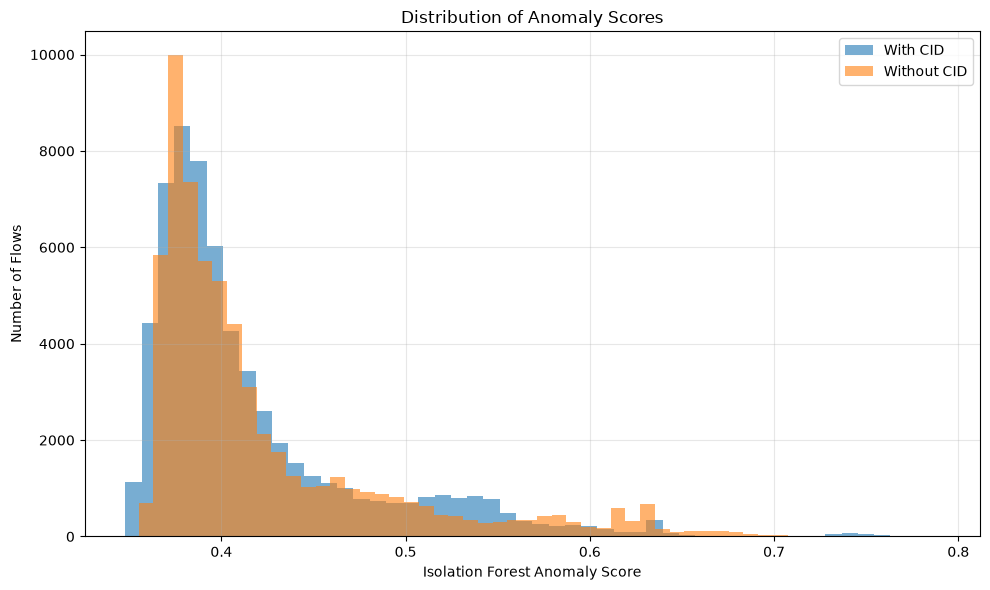

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(with_results["anomaly_score"],
         bins=50,
         alpha=0.6,
         label="With CID")

plt.hist(without_results["anomaly_score"],
         bins=50,
         alpha=0.6,
         label="Without CID")

plt.xlabel("Isolation Forest Anomaly Score")
plt.ylabel("Number of Flows")
plt.title("Distribution of Anomaly Scores")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
summary = pd.DataFrame({
    "With CID": with_results["anomaly_score"].describe(),
    "Without CID": without_results["anomaly_score"].describe()
})

summary

,With CID,Without CID
count,62217.000000,62217.000000
mean,0.417287,0.422834
std,0.062216,0.067325
min,0.347878,0.355153
25%,0.377184,0.378281
50%,0.394556,0.397373
75%,0.432100,0.437401
max,0.789663,0.755400


In [8]:
# Flow indices predicted as anomalies
with_anomalies = set(
    with_results.loc[
        with_results["prediction"] == -1,
        "flow_index"
    ]
)

without_anomalies = set(
    without_results.loc[
        without_results["prediction"] == -1,
        "flow_index"
    ]
)

# Groups
common_anomalies = with_anomalies & without_anomalies
cid_only = with_anomalies - without_anomalies
baseline_only = without_anomalies - with_anomalies

print("Common anomalies :", len(common_anomalies))
print("CID-only anomalies :", len(cid_only))
print("Baseline-only anomalies :", len(baseline_only))

Common anomalies : 4948
CID-only anomalies : 2524
Baseline-only anomalies : 2737


In [9]:
comparison = pd.DataFrame({

    "Group":[
        "Common",
        "CID Only",
        "Baseline Only"
    ],

    "Count":[
        len(common_anomalies),
        len(cid_only),
        len(baseline_only)
    ]

})

comparison

,Group,Count
0,Common,4948
1,CID Only,2524
2,Baseline Only,2737


In [10]:
overlap_with = (
    len(common_anomalies) /
    len(with_anomalies)
) * 100

overlap_without = (
    len(common_anomalies) /
    len(without_anomalies)
) * 100

print(f"Overlap with CID anomalies : {overlap_with:.2f}%")
print(f"Overlap without CID anomalies : {overlap_without:.2f}%")

Overlap with CID anomalies : 66.22%
Overlap without CID anomalies : 64.39%


In [11]:
comparison_df = pd.DataFrame({
    "flow_index": with_results["flow_index"]
})

comparison_df["group"] = "Normal"

comparison_df.loc[
    comparison_df.flow_index.isin(common_anomalies),
    "group"
] = "Common"

comparison_df.loc[
    comparison_df.flow_index.isin(cid_only),
    "group"
] = "CID Only"

comparison_df.loc[
    comparison_df.flow_index.isin(baseline_only),
    "group"
] = "Baseline Only"

comparison_df["group"].value_counts()

group
Normal           52008
Common            4948
Baseline Only     2737
CID Only          2524
Name: count, dtype: int64

In [12]:
comparison_features = with_features.merge(
    comparison_df,
    left_index=True,
    right_on="flow_index"
)

comparison_features.head()

,PPI_LEN,PPI_ROUNDTRIPS,log_ppi_duration,log_mean_ipt,log_std_ipt,mean_packet_size,std_packet_size,direction_change_ratio,forward_packet_ratio,occid_length,...,log_byte_ratio,log_packet_ratio,quic_version_id,QUIC_TOKEN_LENGTH,log_zero_rtt,zero_rtt_present,log_multiplexed,multiplexed,flow_index,group
0,30,4,0.020783,0.530628,1.156227,582.733333,600.943255,0.241379,0.400000,6,...,0.257596,0.528067,1,0,0.000000,0,0.0,0,81886,Normal
1,30,5,0.171429,1.978700,2.860922,541.033333,550.586262,0.344828,0.500000,0,...,0.395914,0.723919,1,70,0.693147,1,0.0,0,200552,Normal
2,30,7,0.217528,2.208274,3.031440,571.600000,564.817941,0.482759,0.500000,0,...,0.736707,0.712950,1,0,0.000000,0,0.0,0,294573,Normal
3,30,6,0.061095,1.131402,1.682100,593.466667,608.400073,0.413793,0.500000,6,...,0.449263,0.693147,1,0,0.000000,0,0.0,0,136922,Normal
4,26,7,0.232698,2.404864,3.332557,574.730769,607.116803,0.520000,0.423077,6,...,0.172884,0.550046,1,0,0.000000,0,0.0,0,166186,Normal


In [13]:
anomaly_groups = comparison_features[
    comparison_features["group"] != "Normal"
].copy()

anomaly_groups["group"].value_counts()

group
Common           4948
Baseline Only    2737
CID Only         2524
Name: count, dtype: int64

In [14]:
cid_features = [

    "occid_length",
    "oscid_length",
    "scid_length",

    "oscid_entropy",
    "scid_entropy",

    "oscid_entropy_deviation",
    "scid_entropy_deviation",

    "oscid_length_deviation",
    "scid_length_deviation",

    "retry_present",
    "known_asn"

]

cid_summary = (
    anomaly_groups
    .groupby("group")[cid_features]
    .mean()
    .round(3)
)

cid_summary

,occid_length,oscid_length,scid_length,oscid_entropy,scid_entropy,oscid_entropy_deviation,scid_entropy_deviation,oscid_length_deviation,scid_length_deviation,retry_present,known_asn
group,,,,,,,,,,,
Baseline Only,0.729,16.337,16.504,0.803,0.797,0.040,0.039,0.337,0.000,0.000,1.000
CID Only,11.320,21.965,17.265,0.841,0.801,0.066,0.048,5.965,0.211,0.002,0.943
Common,14.679,23.408,17.614,0.849,0.799,0.066,0.052,7.408,0.310,0.000,0.992


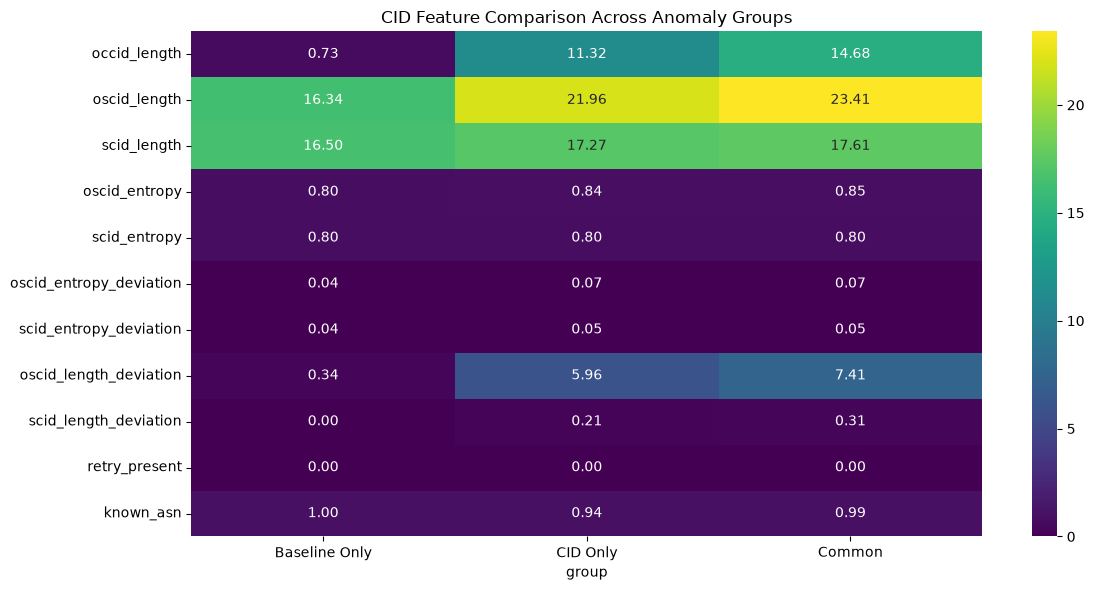

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.heatmap(
    cid_summary.T,
    annot=True,
    cmap="viridis",
    fmt=".2f"
)

plt.title("CID Feature Comparison Across Anomaly Groups")
plt.tight_layout()
plt.show()

In [16]:
quic_features = [

    "quic_version_id",
    "QUIC_TOKEN_LENGTH",
    "log_zero_rtt",
    "zero_rtt_present",
    "log_multiplexed",
    "multiplexed"

]

quic_summary = (
    anomaly_groups
    .groupby("group")[quic_features]
    .mean()
    .round(3)
)

quic_summary

,quic_version_id,QUIC_TOKEN_LENGTH,log_zero_rtt,zero_rtt_present,log_multiplexed,multiplexed
group,,,,,,
Baseline Only,1.476,52.062,1.161,0.708,0.004,0.005
CID Only,2.422,21.685,0.115,0.130,0.000,0.000
Common,1.765,27.447,0.258,0.198,0.287,0.358


In [17]:
flow_features = [

    "log_duration",
    "log_total_bytes",
    "log_byte_rate",
    "avg_packet_size",
    "log_byte_ratio",
    "log_packet_ratio"

]

flow_summary = (
    anomaly_groups
    .groupby("group")[flow_features]
    .mean()
    .round(3)
)

flow_summary

,log_duration,log_total_bytes,log_byte_rate,avg_packet_size,log_byte_ratio,log_packet_ratio
group,,,,,,
Baseline Only,2.044,10.588,9.563,622.910,0.711,0.592
CID Only,1.970,10.881,9.855,593.248,0.849,0.686
Common,2.095,10.436,9.903,783.549,0.800,0.587


In [18]:
ppi_features = [

    "PPI_LEN",
    "PPI_ROUNDTRIPS",
    "log_ppi_duration",
    "log_mean_ipt",
    "log_std_ipt",

    "mean_packet_size",
    "std_packet_size",

    "direction_change_ratio",
    "forward_packet_ratio",

    "src_size_entropy",
    "dst_size_entropy",

    "src_ipt_entropy",
    "dst_ipt_entropy"

]

ppi_summary = (
    anomaly_groups
    .groupby("group")[ppi_features]
    .mean()
    .round(3)
)

ppi_summary

,PPI_LEN,PPI_ROUNDTRIPS,log_ppi_duration,log_mean_ipt,log_std_ipt,mean_packet_size,std_packet_size,direction_change_ratio,forward_packet_ratio,src_size_entropy,dst_size_entropy,src_ipt_entropy,dst_ipt_entropy
group,,,,,,,,,,,,,
Baseline Only,25.829,4.554,1.172,3.388,4.311,593.024,490.105,0.375,0.445,0.513,0.496,0.337,0.324
CID Only,27.802,4.950,0.417,2.070,2.841,557.839,517.104,0.368,0.513,0.499,0.497,0.331,0.325
Common,22.202,4.265,0.573,2.222,2.792,765.972,430.210,0.487,0.450,0.357,0.338,0.279,0.335


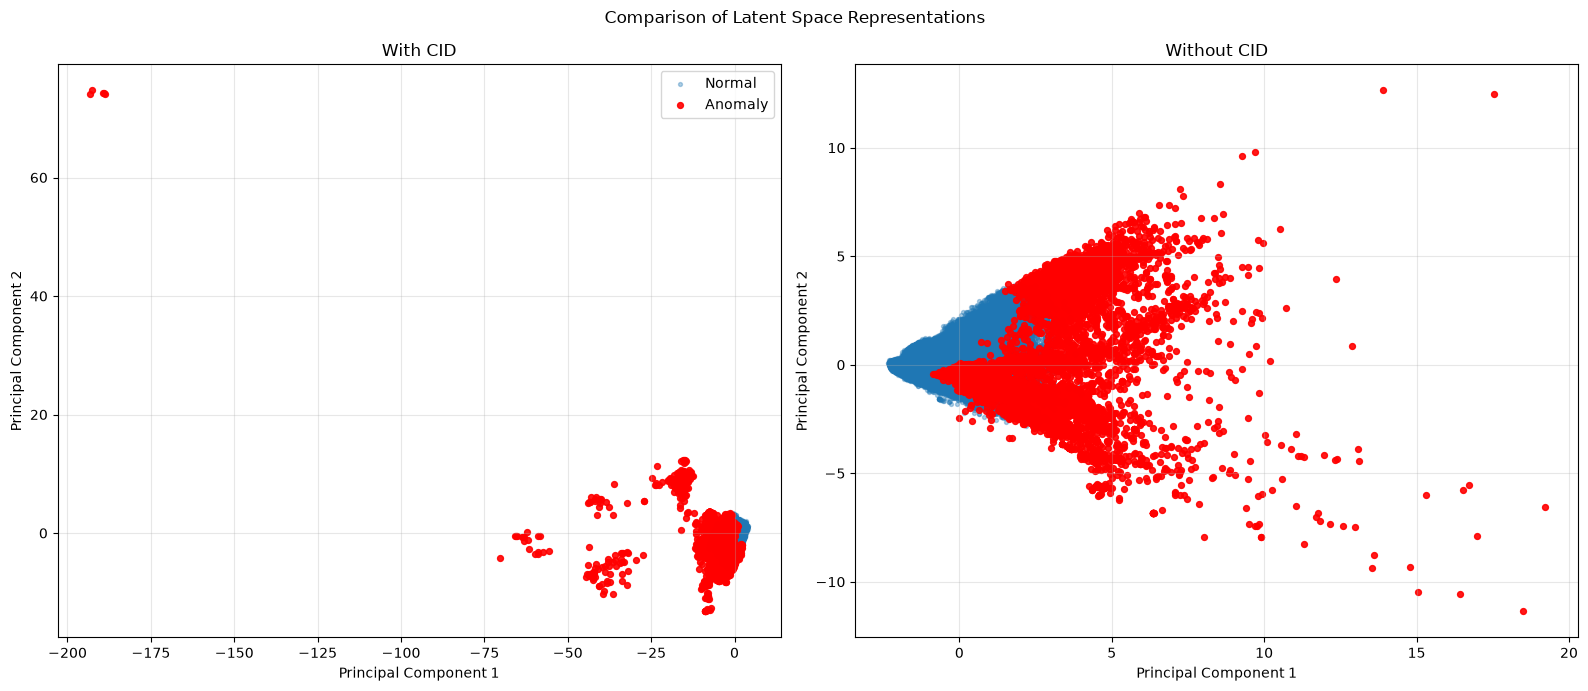

In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

latent_cols = [f"latent_{i}" for i in range(1, 11)]

fig, axes = plt.subplots(1, 2, figsize=(16,7))

models = [
    (with_results, "With CID"),
    (without_results, "Without CID")
]

for ax, (df, title) in zip(axes, models):

    pca = PCA(n_components=2, random_state=42)
    pcs = pca.fit_transform(df[latent_cols])

    normal = df["prediction"] == 1
    anomaly = df["prediction"] == -1

    ax.scatter(
        pcs[normal,0],
        pcs[normal,1],
        s=8,
        alpha=0.35,
        label="Normal"
    )

    ax.scatter(
        pcs[anomaly,0],
        pcs[anomaly,1],
        s=18,
        color="red",
        alpha=0.9,
        label="Anomaly"
    )

    ax.set_title(title)
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.grid(alpha=0.3)

axes[0].legend()

plt.suptitle("Comparison of Latent Space Representations")
plt.tight_layout()
plt.show()

In [20]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Latent feature columns
latent_cols = [f"latent_{i}" for i in range(1, 11)]


X_with = with_results[latent_cols]
y_with = with_results["prediction"]

silhouette_with = silhouette_score(X_with, y_with)
db_with = davies_bouldin_score(X_with, y_with)


X_without = without_results[latent_cols]
y_without = without_results["prediction"]

silhouette_without = silhouette_score(X_without, y_without)
db_without = davies_bouldin_score(X_without, y_without)


comparison_metrics = pd.DataFrame({
    "Metric": ["Silhouette Score", "Davies-Bouldin Index"],
    "With CID": [silhouette_with, db_with],
    "Without CID": [silhouette_without, db_without]
})

comparison_metrics

,Metric,With CID,Without CID
0,Silhouette Score,0.531134,0.514044
1,Davies-Bouldin Index,1.368424,1.675837


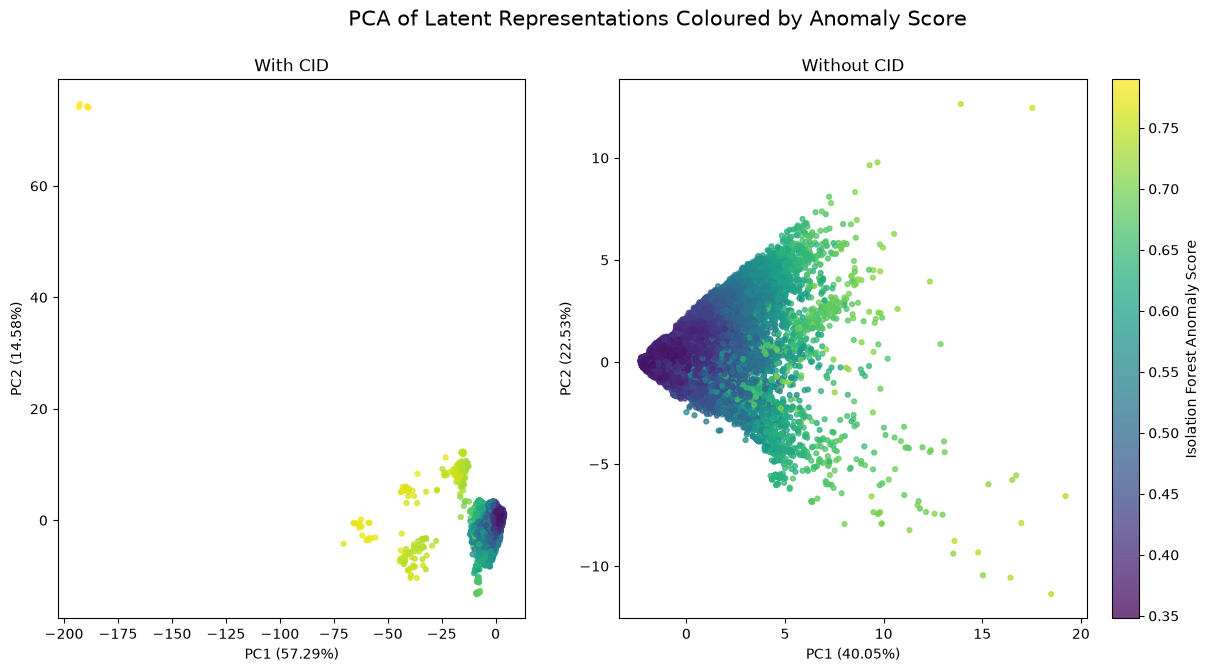

In [21]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

latent_cols = [f"latent_{i}" for i in range(1, 11)]

# Latent representations
latent_with = with_results[latent_cols].values
latent_without = without_results[latent_cols].values

# PCA
pca_with = PCA(n_components=2, random_state=42)
pcs_with = pca_with.fit_transform(latent_with)

pca_without = PCA(n_components=2, random_state=42)
pcs_without = pca_without.fit_transform(latent_without)

# Common colour scale
vmin = min(with_results["anomaly_score"].min(),
           without_results["anomaly_score"].min())

vmax = max(with_results["anomaly_score"].max(),
           without_results["anomaly_score"].max())

fig, axes = plt.subplots(1, 2, figsize=(16,7))


sc1 = axes[0].scatter(
    pcs_with[:,0],
    pcs_with[:,1],
    c=with_results["anomaly_score"],
    cmap="viridis",
    s=12,
    alpha=0.75,
    vmin=vmin,
    vmax=vmax
)

axes[0].set_title("With CID")
axes[0].set_xlabel(
    f"PC1 ({pca_with.explained_variance_ratio_[0]*100:.2f}%)"
)
axes[0].set_ylabel(
    f"PC2 ({pca_with.explained_variance_ratio_[1]*100:.2f}%)"
)


sc2 = axes[1].scatter(
    pcs_without[:,0],
    pcs_without[:,1],
    c=without_results["anomaly_score"],
    cmap="viridis",
    s=12,
    alpha=0.75,
    vmin=vmin,
    vmax=vmax
)

axes[1].set_title("Without CID")
axes[1].set_xlabel(
    f"PC1 ({pca_without.explained_variance_ratio_[0]*100:.2f}%)"
)
axes[1].set_ylabel(
    f"PC2 ({pca_without.explained_variance_ratio_[1]*100:.2f}%)"
)

# Shared colourbar
cbar = fig.colorbar(sc2, ax=axes.ravel().tolist(), pad=0.02)
cbar.set_label("Isolation Forest Anomaly Score")

fig.suptitle(
    "PCA of Latent Representations Coloured by Anomaly Score",
    fontsize=15
)


plt.show()

In [22]:
from scipy.stats import spearmanr, pearsonr

# Scores
cid_scores = with_results['anomaly_score']
baseline_scores = without_results['anomaly_score']

# Pearson correlation
pearson_corr, pearson_p = pearsonr(cid_scores, baseline_scores)

# Spearman correlation
spearman_corr, spearman_p = spearmanr(cid_scores, baseline_scores)

print("="*50)
print("ANOMALY SCORE CORRELATION")
print("="*50)

print(f"Pearson Correlation  : {pearson_corr:.4f}")
print(f"Pearson p-value      : {pearson_p:.4e}")

print()

print(f"Spearman Correlation : {spearman_corr:.4f}")
print(f"Spearman p-value     : {spearman_p:.4e}")

ANOMALY SCORE CORRELATION
Pearson Correlation  : 0.7534
Pearson p-value      : 0.0000e+00

Spearman Correlation : 0.6936
Spearman p-value     : 0.0000e+00
